# ECG Preprocessing and Feature Engineering

This notebook reproduces the locked preprocessing artifacts used by notebooks 03–06. No model is trained and no scientific setting is changed.

## 1. Setup and Environment

Display the active Jupyter kernel rather than assuming a particular virtual environment.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb
from scipy.signal import butter, sosfiltfilt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

RAW = ROOT / "data/raw/mitdb"
PROCESSED = ROOT / "data/processed"
FIGURES = ROOT / "figures"
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

records = [
    line.strip()
    for line in (RAW / "RECORDS").read_text().splitlines()
    if line.strip().isdigit()
]
assert len(records) == 48

AAMI_MAP = {
    "N": "N", "L": "N", "R": "N", "e": "N", "j": "N",
    "A": "S", "a": "S", "J": "S", "S": "S",
    "V": "V", "E": "V", "F": "F",
    "/": "Q", "f": "Q", "Q": "Q", "?": "Q",
}
FINAL_CLASSES = ["N", "S", "V", "F"]
PRE_SAMPLES = 100
POST_SAMPLES = 180
SEGMENT_LENGTH = PRE_SAMPLES + POST_SAMPLES

splits = {
    "train": (PROCESSED / "train_records.txt").read_text().split(),
    "val": (PROCESSED / "validation_records.txt").read_text().split(),
    "test": (PROCESSED / "test_records.txt").read_text().split(),
}
split_sets = {name: set(ids) for name, ids in splits.items()}
assert split_sets["train"].isdisjoint(split_sets["val"])
assert split_sets["train"].isdisjoint(split_sets["test"])
assert split_sets["val"].isdisjoint(split_sets["test"])

channel_selection = pd.read_csv(
    PROCESSED / "channel_selection.csv",
    dtype={"record_id": str},
).set_index("record_id")
print("Python version:", sys.version)
print("Package versions:", {"numpy": np.__version__, "pandas": pd.__version__, "scipy": __import__("scipy").__version__, "wfdb": wfdb.__version__})
print("Records per split:", {name: len(ids) for name, ids in splits.items()})


## 2. Load Frozen Split Information

Use the fixed record lists created before modelling; records never move between partitions.

In [2]:
split_summary = pd.DataFrame({'Split': list(splits), 'Records': [len(v) for v in splits.values()]})
display(split_summary)

,Split,Records
0,train,32
1,val,8
2,test,8


## 3. Load Channel Selection

Reuse the verified MLII-by-name channel table, including V5 exceptions for records 102 and 104.

In [3]:
display(channel_selection.reset_index().head())
assert (channel_selection['selected_lead'] == 'MLII').sum() == 46

,record_id,selected_channel_index,selected_lead,all_leads,used_alternative
0,100,0,MLII,MLII|V5,False
1,101,0,MLII,MLII|V1,False
2,102,0,V5,V5|V2,True
3,103,0,MLII,MLII|V2,False
4,104,0,V5,V5|V2,True


## 4. Define Filtering Parameters

Retain the third-order 0.5–40 Hz Butterworth SOS design and zero-phase filtering.

In [4]:
FILTER_ORDER = 3
LOW_CUTOFF_HZ = 0.5
HIGH_CUTOFF_HZ = 40

def design_bandpass_filter(fs):
    return butter(
        FILTER_ORDER,
        [LOW_CUTOFF_HZ, HIGH_CUTOFF_HZ],
        btype="bandpass",
        fs=fs,
        output="sos",
    )

def bandpass_filter(signal, fs):
    # Forward-backward SOS filtering preserves annotation alignment.
    sos = design_bandpass_filter(fs)
    return sosfiltfilt(sos, signal)


## 5. Demonstrate Raw vs Filtered ECG

Compare the same deterministic MLII segment using common time and amplitude axes.

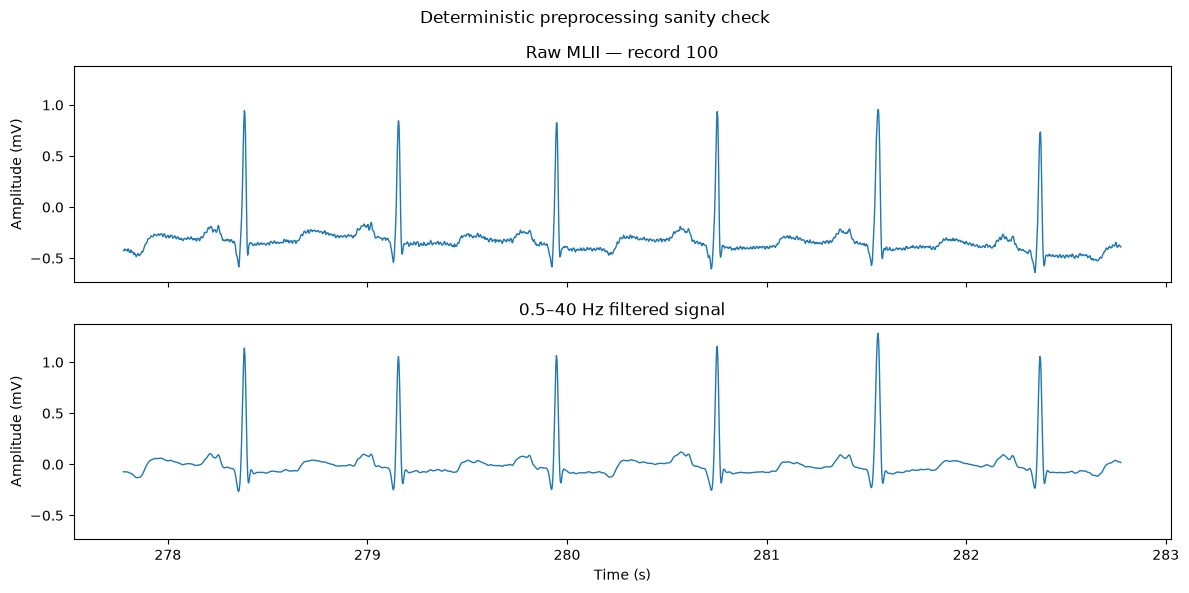

In [5]:
example_record_id = "100"
example_record = wfdb.rdrecord(str(RAW / example_record_id))
example_channel = int(channel_selection.loc[example_record_id, "selected_channel_index"])
example_lead = channel_selection.loc[example_record_id, "selected_lead"]
example_raw = example_record.p_signal[:, example_channel]
example_filtered = bandpass_filter(example_raw, example_record.fs)

start_sample = 100000
stop_sample = start_sample + int(5 * example_record.fs)
time_seconds = np.arange(start_sample, stop_sample) / example_record.fs

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(time_seconds, example_raw[start_sample:stop_sample], linewidth=1)
axes[0].set(ylabel="Amplitude (mV)", title=f"Raw {example_lead} — record 100")
axes[1].plot(time_seconds, example_filtered[start_sample:stop_sample], linewidth=1)
axes[1].set(xlabel="Time (s)", ylabel="Amplitude (mV)", title="0.5–40 Hz filtered signal")
comparison_values = np.concatenate([
    example_raw[start_sample:stop_sample],
    example_filtered[start_sample:stop_sample],
])
amplitude_margin = 0.05 * np.ptp(comparison_values)
shared_limits = (
    comparison_values.min() - amplitude_margin,
    comparison_values.max() + amplitude_margin,
)
axes[0].set_ylim(shared_limits)
axes[1].set_ylim(shared_limits)
fig.suptitle("Deterministic preprocessing sanity check")
fig.tight_layout()
fig.savefig(FIGURES / "preprocessing_raw_vs_filtered.png", dpi=220)
plt.show()


The filtered trace preserves the timing and visible heartbeat morphology while reducing slow baseline variation and higher-frequency fluctuation. This visual check demonstrates the operation on a deterministic MLII segment; it does not imply complete noise removal.


## 6. Define Heartbeat Segmentation Window

Use 100 samples before and 180 after each annotation: 280 samples in total.

In [6]:
def has_complete_window(centre_sample, signal_length):
    return (
        centre_sample >= PRE_SAMPLES
        and centre_sample + POST_SAMPLES <= signal_length
    )

def extract_heartbeat_window(filtered_signal, centre_sample):
    start = centre_sample - PRE_SAMPLES
    stop = centre_sample + POST_SAMPLES
    return filtered_signal[start:stop].astype(np.float32)

def standardise_beat(beat):
    beat_mean = beat.mean()
    beat_std = float(beat.std())
    denominator = beat_std if beat_std > 1e-8 else 1.0
    return ((beat - beat_mean) / denominator).astype(np.float32)


In [7]:
segmentation_parameters = pd.DataFrame({
 'Parameter':['Before annotation','After annotation','Total window'],
 'Samples':[PRE_SAMPLES,POST_SAMPLES,SEGMENT_LENGTH],
 'Seconds':[PRE_SAMPLES/360,POST_SAMPLES/360,SEGMENT_LENGTH/360],
})
display(segmentation_parameters)

,Parameter,Samples,Seconds
0,Before annotation,100,0.277778
1,After annotation,180,0.500000
2,Total window,280,0.777778


## 7. Prepare Valid Beat Annotations

Map only the locked N/S/V/F target beats while preserving annotation order.

In [8]:
def get_mapped_beats(annotation):
    mapped_beats = []
    for sample, symbol in zip(annotation.sample, annotation.symbol):
        mapped_class = AAMI_MAP.get(symbol)
        if mapped_class in FINAL_CLASSES:
            mapped_beats.append((int(sample), symbol, mapped_class))
    return mapped_beats



## 8. Calculate RR Context

Compute previous, next, and local RR strictly within each record; undefined edges use that record’s median.

In [9]:
def calculate_rr_context(mapped_beats, fs):
    beat_samples = np.array([beat[0] for beat in mapped_beats], dtype=int)
    rr_intervals = np.diff(beat_samples) / fs
    record_median_rr = float(np.median(rr_intervals)) if len(rr_intervals) else 1.0
    contexts = []

    for beat_index in range(len(mapped_beats)):
        previous_rr = rr_intervals[beat_index - 1] if beat_index > 0 else np.nan
        next_rr = rr_intervals[beat_index] if beat_index < len(rr_intervals) else np.nan

        local_start = max(0, beat_index - 10)
        local_candidates = rr_intervals[local_start:beat_index]
        local_rr = (
            float(np.median(local_candidates))
            if len(local_candidates)
            else np.nan
        )

        if not np.isfinite(previous_rr):
            previous_rr = record_median_rr
        if not np.isfinite(next_rr):
            next_rr = record_median_rr
        if not np.isfinite(local_rr):
            local_rr = record_median_rr

        contexts.append((float(previous_rr), float(next_rr), float(local_rr)))
    return contexts


## 9. Extract One Example Heartbeat

Extract one complete mapped window from record 100 to make segmentation concrete.

In [10]:
example_annotation = wfdb.rdann(str(RAW / example_record_id), 'atr')
example_beats = get_mapped_beats(example_annotation)
example_sample, example_symbol, example_class = example_beats[10]
example_filtered = bandpass_filter(example_raw, example_record.fs)
example_heartbeat = extract_heartbeat_window(example_filtered, example_sample)
print({'sample': example_sample, 'symbol': example_symbol, 'class': example_class, 'shape': example_heartbeat.shape})

{'sample': 2998, 'symbol': 'N', 'class': 'N', 'shape': (280,)}


## 10. Normalise One Heartbeat

Standardise each window independently; no dataset-wide CNN scaler is fitted.

In [11]:
example_normalised = standardise_beat(example_heartbeat)
print({'mean': float(example_normalised.mean()), 'std': float(example_normalised.std())})

{'mean': 1.362391888193315e-08, 'std': 1.0}


## 11. Define Engineered Features

Keep the exact five rhythm, nine waveform-statistic, and four morphology/change features.

In [12]:
def extract_features(beat, previous_rr, next_rr, local_rr):
    # Rhythm/context features
    previous_rr_relative = previous_rr / local_rr
    previous_rr_deviation = previous_rr - local_rr

    # Waveform statistics
    wave_mean = beat.mean()
    wave_std = beat.std()
    wave_variance = beat.var()
    wave_min = beat.min()
    wave_max = beat.max()
    wave_range = np.ptp(beat)
    wave_median = np.median(beat)
    wave_energy = np.mean(beat * beat)
    wave_absolute_area = np.trapezoid(np.abs(beat), dx=1 / 360)

    # Morphology/change features
    differences = np.diff(beat)
    local_qrs = beat[PRE_SAMPLES - 36:PRE_SAMPLES + 37]
    maximum_absolute_slope = np.max(np.abs(differences)) * 360
    mean_absolute_slope = np.mean(np.abs(differences)) * 360
    local_qrs_range = np.ptp(local_qrs)
    zero_crossings = int(np.sum(np.diff(np.signbit(beat)) != 0))

    return {
        "rr_previous_s": previous_rr,
        "rr_next_s": next_rr,
        "rr_local_mean_s": local_rr,
        "rr_previous_relative": previous_rr_relative,
        "rr_previous_deviation_s": previous_rr_deviation,
        "wave_mean": wave_mean,
        "wave_std": wave_std,
        "wave_variance": wave_variance,
        "wave_min": wave_min,
        "wave_max": wave_max,
        "wave_range": wave_range,
        "wave_median": wave_median,
        "wave_energy": wave_energy,
        "wave_abs_area": wave_absolute_area,
        "max_abs_slope": maximum_absolute_slope,
        "mean_abs_slope": mean_absolute_slope,
        "qrs_local_range": local_qrs_range,
        "zero_crossings": zero_crossings,
    }

EXPECTED_FEATURES = [
    "rr_previous_s", "rr_next_s", "rr_local_mean_s",
    "rr_previous_relative", "rr_previous_deviation_s",
    "wave_mean", "wave_std", "wave_variance", "wave_min", "wave_max",
    "wave_range", "wave_median", "wave_energy", "wave_abs_area",
    "max_abs_slope", "mean_abs_slope", "qrs_local_range", "zero_crossings",
]
assert len(EXPECTED_FEATURES) == 18


## 12. Process Training Data

Run the shared function explicitly for the 32 training records.

In [13]:
def process_split(record_ids, split_name):
    """Process one frozen record partition and return aligned rows."""
    metadata_rows, waveform_rows, feature_rows, label_rows, exclusions = [], [], [], [], []
    for record_id in record_ids:
        record = wfdb.rdrecord(str(RAW / record_id))
        annotation = wfdb.rdann(str(RAW / record_id), "atr")
        channel_index = int(channel_selection.loc[record_id, "selected_channel_index"])
        selected_lead = channel_selection.loc[record_id, "selected_lead"]
        filtered_signal = bandpass_filter(record.p_signal[:, channel_index], record.fs)
        mapped_beats = get_mapped_beats(annotation)
        rr_contexts = calculate_rr_context(mapped_beats, record.fs)
        for beat_index, (beat, rr_values) in enumerate(zip(mapped_beats, rr_contexts)):
            sample, symbol, mapped_class = beat
            if not has_complete_window(sample, record.sig_len):
                exclusions.append({"split": split_name, "class": mapped_class})
                continue
            waveform = standardise_beat(extract_heartbeat_window(filtered_signal, sample))
            beat_id = f"{record_id}_{sample}_{beat_index}"
            provenance = {"beat_id": beat_id, "record_id": record_id, "annotation_sample": sample,
                          "annotation_symbol": symbol, "mapped_class": mapped_class,
                          "split": split_name, "selected_lead": selected_lead}
            metadata_rows.append(provenance)
            waveform_rows.append(waveform)
            label_rows.append(mapped_class)
            feature_rows.append({**provenance, **extract_features(waveform, *rr_values)})
    return metadata_rows, waveform_rows, feature_rows, label_rows, exclusions


In [14]:
train_output = process_split(splits['train'], 'train')
print('Training beats:', len(train_output[0]))

Training beats: 71065


## 13. Process Validation Data

Process the frozen validation records separately.

In [15]:
validation_output = process_split(splits['val'], 'val')
print('Validation beats:', len(validation_output[0]))

Validation beats: 15211


## 14. Process Test Data

Process the untouched test records using the same functions.

In [16]:
test_output = process_split(splits['test'], 'test')
print('Test beats:', len(test_output[0]))

Test beats: 15133


## 15. Boundary Exclusions

Count only incomplete 280-sample windows near record boundaries.

In [17]:
outputs = {"train": train_output, "val": validation_output, "test": test_output}
metadata = pd.DataFrame([row for output in outputs.values() for row in output[0]])
classical = {name: pd.DataFrame(output[2]) for name, output in outputs.items()}
waveform_arrays = {name: np.asarray(output[1], dtype=np.float32)[..., None] for name, output in outputs.items()}
label_arrays = {name: np.asarray(output[3], dtype="<U1") for name, output in outputs.items()}
exclusion_rows = [row for output in outputs.values() for row in output[4]]
feature_names = EXPECTED_FEATURES.copy()

exclusions = pd.DataFrame(exclusion_rows).groupby(['split','class']).size().unstack(fill_value=0).reindex(index=['train','val','test'], columns=FINAL_CLASSES, fill_value=0)
exclusions['total'] = exclusions.sum(axis=1)
display(exclusions)
assert exclusions['total'].to_dict() == {'train':29,'val':7,'test':6}

class,N,S,V,F,total
split,,,,,
train,28,0,0,1,29
val,7,0,0,0,7
test,5,0,1,0,6


## 16. Feature Summary

Summarise all 18 training features without using validation or test statistics.

In [18]:
feature_summary = classical['train'][feature_names].agg(['mean','std','median','min','max']).T.reset_index(names='Feature')
display(feature_summary)

,Feature,mean,std,median,min,max
0,rr_previous_s,8.110839e-01,9.492965e-01,0.744444,2.500000e-01,1.000222e+02
1,rr_next_s,8.110785e-01,9.492940e-01,0.744444,2.500000e-01,1.000222e+02
2,rr_local_mean_s,7.884193e-01,4.183345e-01,0.738889,2.958333e-01,2.713472e+01
3,rr_previous_relative,1.023703e+00,5.649689e-01,1.000000,5.818966e-02,8.492453e+01
4,rr_previous_deviation_s,2.266460e-02,7.709112e-01,0.000000,-1.905972e+01,9.884444e+01
5,wave_mean,-7.592343e-11,1.671851e-08,0.000000,-1.089914e-07,1.362392e-07
6,wave_std,1.000000e+00,3.949938e-08,1.000000,9.999998e-01,1.000000e+00
7,wave_variance,1.000000e+00,9.763765e-08,1.000000,9.999997e-01,1.000000e+00
8,wave_min,-1.792399e+00,9.750450e-01,-1.429860,-7.326686e+00,-4.883046e-01
9,wave_max,4.812372e+00,1.297852e+00,4.838413,8.846712e-01,7.563506e+00


## 17. Feature Distribution by Class

Compare four representative rhythm and morphology features descriptively.

,class,feature,median,q1,q3,iqr
0,N,rr_previous_s,0.763889,0.686111,0.900000,0.213889
1,N,rr_local_mean_s,0.744444,0.676389,0.872222,0.195833
2,N,qrs_local_range,6.572532,5.800261,7.457484,1.657223
3,N,max_abs_slope,415.449707,274.140022,502.080315,227.940292
4,S,rr_previous_s,0.719444,0.611111,0.741667,0.130556
5,S,rr_local_mean_s,0.737500,0.723611,0.751389,0.027778
6,S,qrs_local_range,7.186777,6.731761,7.467354,0.735593
7,S,max_abs_slope,498.120544,444.763000,524.299683,79.536682
8,V,rr_previous_s,0.522222,0.472222,0.561111,0.088889
9,V,rr_local_mean_s,0.679167,0.577778,0.802778,0.225000


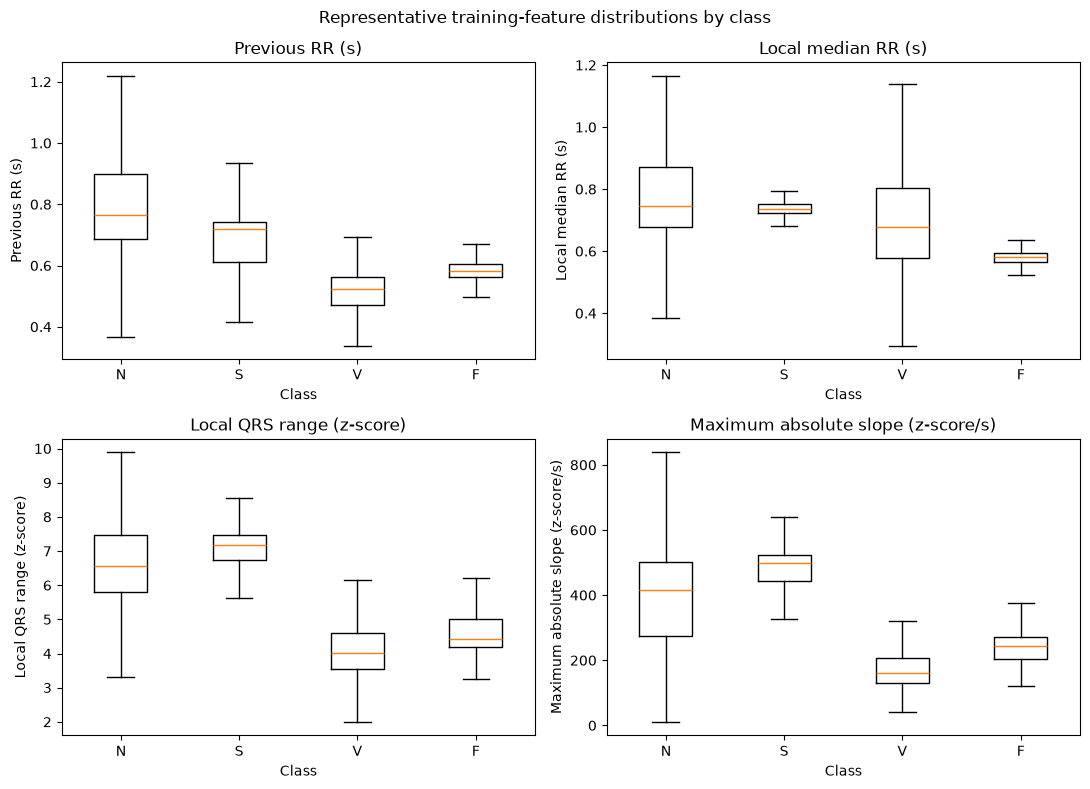

In [19]:
selected_features = [
    "rr_previous_s",
    "rr_local_mean_s",
    "qrs_local_range",
    "max_abs_slope",
]
feature_labels = {
    "rr_previous_s": "Previous RR (s)",
    "rr_local_mean_s": "Local median RR (s)",
    "qrs_local_range": "Local QRS range (z-score)",
    "max_abs_slope": "Maximum absolute slope (z-score/s)",
}
training_features = classical["train"]

summary_rows = []
for class_name in FINAL_CLASSES:
    class_rows = training_features[training_features["mapped_class"] == class_name]
    for feature_name in selected_features:
        values = class_rows[feature_name]
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        summary_rows.append({
            "class": class_name,
            "feature": feature_name,
            "median": values.median(),
            "q1": q1,
            "q3": q3,
            "iqr": q3 - q1,
        })
feature_summary = pd.DataFrame(summary_rows)
display(feature_summary)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, feature_name in zip(axes.ravel(), selected_features):
    values_by_class = [
        training_features.loc[
            training_features["mapped_class"] == class_name,
            feature_name,
        ].to_numpy()
        for class_name in FINAL_CLASSES
    ]
    ax.boxplot(values_by_class, tick_labels=FINAL_CLASSES, showfliers=False)
    ax.set(xlabel="Class", ylabel=feature_labels[feature_name], title=feature_labels[feature_name])
fig.suptitle("Representative training-feature distributions by class")
fig.tight_layout()
fig.savefig(FIGURES / "preprocessing_feature_distributions.png", dpi=220)
plt.show()


Previous and local RR describe rhythm context, while local QRS range and maximum absolute slope describe morphology and waveform change. Their class-dependent medians and spreads show potentially useful structure without proving statistical significance or causation. Together, the five rhythm features and thirteen waveform/morphology features provide the compact 18-feature input used unchanged by Logistic Regression and Random Forest.


## 18. Save Processed Data

Save classical CSVs, CNN arrays, labels, and metadata under the original filenames.

In [20]:
for split_name in splits:
    classical[split_name].to_csv(PROCESSED / f"classical_{split_name}.csv", index=False)
    np.save(PROCESSED / f"cnn_X_{split_name}.npy", waveform_arrays[split_name])
    np.save(PROCESSED / f"y_{split_name}.npy", label_arrays[split_name])
metadata.to_csv(PROCESSED / "beat_metadata.csv", index=False)
print("Saved aligned processed artifacts.")

Saved aligned processed artifacts.


## 19. Integrity and Leakage Checks

Reload outputs and visibly verify alignment, finiteness, classes, dimensions, and record independence.

In [21]:
metadata_columns = {"beat_id", "record_id", "annotation_sample", "annotation_symbol", "mapped_class", "split", "selected_lead"}
checks = {}
checks["record sets disjoint"] = all(
    split_sets[first].isdisjoint(split_sets[second])
    for first, second in [("train", "val"), ("train", "test"), ("val", "test")]
)
checks["201 and 202 kept together"] = any(
    {"201", "202"}.issubset(record_set) for record_set in split_sets.values()
)
checks["all provenance present"] = not metadata[list(metadata_columns)].isna().any().any()
checks["expected labels only"] = set(metadata["mapped_class"]) == set(FINAL_CLASSES)

shape_rows = []
for split_name in splits:
    saved_features = pd.read_csv(
        PROCESSED / f"classical_{split_name}.csv",
        dtype={"record_id": str},
    )
    saved_waveforms = np.load(PROCESSED / f"cnn_X_{split_name}.npy", allow_pickle=False)
    saved_labels = np.load(PROCESSED / f"y_{split_name}.npy", allow_pickle=False)

    checks[f"{split_name}: aligned rows"] = (
        len(saved_features) == len(saved_waveforms) == len(saved_labels)
    )
    checks[f"{split_name}: feature-label alignment"] = np.array_equal(
        saved_features["mapped_class"].to_numpy(),
        saved_labels,
    )
    checks[f"{split_name}: fixed finite waveforms"] = (
        saved_waveforms.shape[1:] == (SEGMENT_LENGTH, 1)
        and np.isfinite(saved_waveforms).all()
    )
    checks[f"{split_name}: 18 finite features"] = (
        saved_features[feature_names].shape[1] == 18
        and np.isfinite(saved_features[feature_names].to_numpy()).all()
    )
    shape_rows.append({
        "split": split_name,
        "classical_shape": str(saved_features.shape),
        "cnn_shape": str(saved_waveforms.shape),
        "label_shape": str(saved_labels.shape),
    })

check_table = pd.Series(checks, name="passed").rename_axis("integrity_check").to_frame()
display(check_table)
display(pd.DataFrame(shape_rows))
assert check_table["passed"].all()
print("All processed artifacts reloaded; alignment and leakage checks passed.")


,passed
integrity_check,
record sets disjoint,True
201 and 202 kept together,True
all provenance present,True
expected labels only,True
train: aligned rows,True
train: feature-label alignment,True
train: fixed finite waveforms,True
train: 18 finite features,True
val: aligned rows,True


,split,classical_shape,cnn_shape,label_shape
0,train,"(71065, 25)","(71065, 280, 1)","(71065,)"
1,val,"(15211, 25)","(15211, 280, 1)","(15211,)"
2,test,"(15133, 25)","(15133, 280, 1)","(15133,)"


All processed artifacts reloaded; alignment and leakage checks passed.


## 20. Report-Ready Tables

Formatted Excel presentation copies use the `PREPROCESSING_` prefix under `report/tables/`; they do not replace scientific CSV/NPY artifacts. The preprocessing table manifest is: `PREPROCESSING_segmentation_parameters.xlsx`, `PREPROCESSING_feature_list.xlsx`, `PREPROCESSING_train_summary.xlsx`, `PREPROCESSING_validation_summary.xlsx`, `PREPROCESSING_test_summary.xlsx`, `PREPROCESSING_boundary_exclusions.xlsx`, `PREPROCESSING_feature_summary_statistics.xlsx`, `PREPROCESSING_feature_distribution_by_class.xlsx`, `PREPROCESSING_integrity_checks.xlsx`, and `PREPROCESSING_summary.xlsx`.

The exports cover segmentation, feature definitions, partition summaries, boundary exclusions, training statistics, class distributions, integrity checks, and the final preprocessing summary.

## 21. Preprocessing Summary

Record the locked scientific settings and verified output result.

## 11. Preprocessing summary

The notebook preserves the locked 0.5–40 Hz third-order zero-phase SOS filter, 100/180-sample segmentation, same-record RR fallback, independent beat-wise standardisation, and exact 18-feature representation. Forty-two incomplete boundary windows are excluded. Saved classical tables, CNN arrays, labels, and provenance remain aligned and finite; no resampling, augmentation, learned imputation, or cross-record statistic is introduced.
